# Tahap 1-3 Penelitian T2DM

Notebook ini disusun untuk menunjukkan alur pembentukan data penelitian secara bertahap dan transparan, mulai dari pemeriksaan sumber data sampai data siap dianalisis.

Tahapan yang dibahas di notebook ini adalah:

1. **Audit & Integrasi Data**
2. **Prepare Data**
3. **EDA Terarah**

Tujuan utamanya adalah agar pembaca bisa melihat dengan jelas:
- sumber data apa saja yang digunakan,
- bagian data mana yang dipertahankan atau diperbarui,
- bagaimana data akhir penelitian dibentuk,
- dan bagaimana data tersebut mulai dieksplorasi sebelum masuk ke tahap modelling.

Di notebook ini, tahap **Prepare Data** tidak berhenti pada pembersihan data saja, tetapi langsung menghasilkan **final dataset** yang kemudian dipakai pada tahap EDA.

In [58]:
from pathlib import Path
from IPython.display import display, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "ProposalRatih.ipynb").exists() else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "stage_01_03"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: d:\Ratih\PracticeFusion
DATA_DIR: d:\Ratih\PracticeFusion\data\raw
OUTPUT_DIR: d:\Ratih\PracticeFusion\outputs\stage_01_03


In [59]:
d1 = pd.read_csv(DATA_DIR / "d1.csv")
d2 = pd.read_csv(DATA_DIR / "d2.csv")
d3 = pd.read_csv(DATA_DIR / "d3.csv")
d4 = pd.read_csv(DATA_DIR / "d4.csv")
d5 = pd.read_csv(DATA_DIR / "d5.csv")

patient_old = pd.read_csv(DATA_DIR / "patient.csv")
diagnosis_old = pd.read_csv(DATA_DIR / "diagnosis.csv")
medication_old = pd.read_csv(DATA_DIR / "medication.csv")
physician_old = pd.read_csv(DATA_DIR / "physician_specialty.csv")

tables = {
    "d1": d1,
    "d2": d2,
    "d3": d3,
    "d4": d4,
    "d5": d5,
    "patient_old": patient_old,
    "diagnosis_old": diagnosis_old,
    "medication_old": medication_old,
    "physician_old": physician_old,
}

for name, df in tables.items():
    print(f"{name:<15} shape={df.shape}")

d1              shape=(10461, 11)
d2              shape=(58800, 23)
d3              shape=(22428, 26)
d4              shape=(86380, 26)
d5              shape=(9948, 6)
patient_old     shape=(9948, 5)
diagnosis_old   shape=(9948, 26)
medication_old  shape=(9836, 2368)
physician_old   shape=(9948, 62)


## 1. Audit & Integrasi Data

Tahap ini bertujuan untuk memahami kualitas dan cakupan masing-masing sumber data sebelum semuanya digabungkan.

Hal-hal yang ingin diperiksa pada bagian ini:
- ukuran masing-masing tabel,
- banyaknya nilai kosong,
- apakah ada `PatientGuid` yang duplikat,
- seberapa besar cakupan pasien pada tiap tabel,
- dan apakah label target konsisten antar sumber data.

Dengan audit ini, proses penggabungan data pada tahap berikutnya menjadi lebih dapat dipertanggungjawabkan.

In [60]:
def audit_table(name, df, key="PatientGuid"):
    result = {
        "table": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_guid": int(df[key].duplicated().sum()) if key in df.columns else np.nan,
        "unique_guid": int(df[key].nunique()) if key in df.columns else np.nan,
    }
    return result

audit_df = pd.DataFrame([audit_table(name, df) for name, df in tables.items()])
display(Markdown("### Ringkasan audit tabel"))
display(audit_df)

### Ringkasan audit tabel

,table,rows,cols,missing_cells,duplicate_guid,unique_guid
0,d1,10461,11,32523,513,9948
1,d2,58800,23,102474,48884,9916
2,d3,22428,26,60419,21553,875
3,d4,86380,26,922581,76534,9846
4,d5,9948,6,0,0,9948
5,patient_old,9948,5,0,0,9948
6,diagnosis_old,9948,26,0,0,9948
7,medication_old,9836,2368,0,0,9836
8,physician_old,9948,62,0,0,9948


In [61]:
d5_keys = set(d5["PatientGuid"])
coverage_rows = []

for name, df in tables.items():
    if "PatientGuid" not in df.columns:
        continue
    keys = set(df["PatientGuid"])
    coverage_rows.append({
        "table": name,
        "n_guid": len(keys),
        "missing_from_d5": len(d5_keys - keys),
        "extra_not_in_d5": len(keys - d5_keys),
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values("table")
display(Markdown("### Coverage PatientGuid terhadap backbone d5"))
display(coverage_df)

display(Markdown("### Label dan demografi dasar dari d5"))
display(d5.head())

### Coverage PatientGuid terhadap backbone d5

,table,n_guid,missing_from_d5,extra_not_in_d5
0,d1,9948,0,0
1,d2,9916,32,0
2,d3,875,9073,0
3,d4,9846,102,0
4,d5,9948,0,0
6,diagnosis_old,9948,0,0
7,medication_old,9836,112,0
5,patient_old,9948,0,0
8,physician_old,9948,0,0


### Label dan demografi dasar dari d5

,PatientGuid,dmIndicator,Gender,YearOfBirth,State,PracticeGuid
0,FB6EFC3D-1A20-4497-9CBD-00027CC5D220,0,M,1929,SD,7BF4DAD8-5F67-4985-B911-20C9E89A3737
1,C6746626-6783-4650-A58F-00065649139A,0,F,1985,TX,E7101967-2FF1-4B0F-8129-B0B429D1D15C
2,E05C6E8F-779F-4594-A388-000C635AE4D3,0,F,1984,NJ,FC01A799-1CAF-464F-A86F-8A666AB86F32
3,EAEBD216-F847-4355-87B2-000D942E08F0,0,M,1959,OH,EEBC95EF-79BE-4542-892E-98D3166BAB20
4,C7F10A80-4934-42D2-8540-000FBEBA75C8,0,F,1990,FL,677BA32E-B4C4-48F2-86E4-08C42B135401


In [62]:
dm_check = patient_old[["PatientGuid", "DMIndicator"]].merge(
    d5[["PatientGuid", "dmIndicator"]],
    on="PatientGuid",
    how="inner"
)
dm_mismatch = int((dm_check["DMIndicator"] != dm_check["dmIndicator"]).sum())
print("Mismatch label patient_old vs d5:", dm_mismatch)

display(Markdown("### Preview d2 sebagai sumber transcript raw"))
display(d2[[
    "PatientGuid", "TranscriptGuid", "VisitYear", "Height", "Weight", "BMI",
    "SystolicBP", "DiastolicBP", "RespiratoryRate", "HeartRate", "Temperature"
]].head(10))

Mismatch label patient_old vs d5: 0


### Preview d2 sebagai sumber transcript raw

,PatientGuid,TranscriptGuid,VisitYear,Height,Weight,BMI,SystolicBP,DiastolicBP,RespiratoryRate,HeartRate,Temperature
0,FB6EFC3D-1A20-4497-9CBD-00027CC5D220,1BFBEC2D-6E4D-4032-98C0-6F576E85B36E,2009,69.0000,128.0000,18.9000,134,72,NaN,NaN,NaN
1,FB6EFC3D-1A20-4497-9CBD-00027CC5D220,5D30ACC4-1D99-482B-964A-8A80DE1F048A,2009,69.0000,128.0000,18.9000,0,0,NaN,NaN,NaN
2,FB6EFC3D-1A20-4497-9CBD-00027CC5D220,E5C73D9C-8FC2-4BCD-A705-6A204B40EB8E,2009,69.0000,131.0000,19.3430,142,66,NaN,NaN,NaN
3,C6746626-6783-4650-A58F-00065649139A,721D128B-F44C-4C10-8037-925674F932EE,2012,66.5000,162.0000,25.7530,112,60,NaN,NaN,98.3000
4,C6746626-6783-4650-A58F-00065649139A,F4C794D2-3F09-4AFC-8142-CFD626D01D49,2011,66.5000,170.0000,27.0250,103,68,NaN,NaN,97.0000
5,E05C6E8F-779F-4594-A388-000C635AE4D3,799204B8-5EC6-4508-9ABA-FF2DF250BCCB,2009,54.0000,200.0000,48.2170,132,98,NaN,NaN,97.8000
6,E05C6E8F-779F-4594-A388-000C635AE4D3,B7E23878-1A27-4CD1-8567-70394DF912BD,2010,64.0000,186.0000,31.9230,112,80,NaN,NaN,98.1000
7,E05C6E8F-779F-4594-A388-000C635AE4D3,C22E3B6D-9C8B-4CBE-9BCF-EAE31C8E635E,2010,64.0000,198.0000,33.9830,124,86,NaN,NaN,97.6000
8,EAEBD216-F847-4355-87B2-000D942E08F0,0C4DC7D5-125D-4C2F-B9DF-FD5C69B1AE98,2011,72.0000,241.0000,32.6820,130,90,20.0000,NaN,97.8000
9,EAEBD216-F847-4355-87B2-000D942E08F0,0DC10097-A29D-4607-8CA9-6DBAE3EE4AFD,2011,72.0000,242.5000,32.8850,135,85,20.0000,NaN,98.7000


### Kesimpulan Sementara Tahap Audit

Berdasarkan hasil audit awal, ada beberapa hal penting yang bisa langsung dicatat.

- `d5` adalah sumber data yang paling stabil untuk dijadikan acuan utama karena mencakup seluruh `9948` pasien dan tidak memiliki missing value.
- Label diabetes antara `patient.csv` lama dan `d5` konsisten, sehingga tidak ditemukan konflik label pada tahap awal integrasi data.
- `medication.csv` tidak tersedia untuk seluruh pasien, sehingga penggunaan tabel ini akan menyebabkan sebagian pasien tidak bisa masuk ke final dataset.
- `d2` memiliki cakupan pasien yang sangat besar dan cukup kuat untuk dijadikan sumber pembangunan ulang fitur transcript, walaupun isinya tetap perlu dibersihkan terlebih dahulu.

Dari hasil audit ini, keputusan integrasi data menjadi lebih jelas: `d5` dipakai sebagai acuan utama pasien dan label, sedangkan transcript diperbarui dari `d2` agar kualitas informasinya lebih meyakinkan.

## 2. Prepare Data

Pada tahap ini, data disiapkan agar menjadi satu tabel analisis yang rapi, konsisten, dan siap dipakai untuk EDA maupun modelling.

Prinsip yang dipakai adalah mempertahankan informasi yang masih baik dari dataset lama, lalu memperbarui bagian yang sebelumnya dinilai kurang kuat atau kurang informatif.

Sumber data yang digunakan adalah:
- `d5` sebagai sumber utama identitas pasien, label diabetes, dan informasi demografi dasar,
- `patient.csv` lama untuk mengambil variabel `Age`,
- `diagnosis.csv`, `medication.csv`, dan `physician_specialty.csv` lama karena bentuk agregatnya sudah siap dipakai,
- `d2.csv` sebagai sumber mentah untuk membangun ulang seluruh fitur transcript.

Dengan pendekatan ini, kita tidak membuang seluruh hasil olahan lama, tetapi juga tidak menerima mentah-mentah bagian transcript yang sebelumnya terlihat kurang masuk akal.

Output dari tahap ini adalah **final dataset** yang sudah menggabungkan seluruh informasi penting per pasien dalam satu baris.

In [63]:
def clean_transcript_series(series, low=None, high=None):
    s = pd.to_numeric(series, errors="coerce")
    s = s.mask(s <= 0)
    if low is not None:
        s = s.mask(s < low)
    if high is not None:
        s = s.mask(s > high)
    return s

def build_change_by_year(df, value_col):
    valid = df.loc[df[value_col].notna(), ["PatientGuid", "VisitYear", value_col]].copy()
    if valid.empty:
        return pd.Series(data=[], index=pd.Index([], name="PatientGuid"), dtype=float, name=f"{value_col}_Change")

    yearly = (
        valid.groupby(["PatientGuid", "VisitYear"], as_index=False)[value_col]
        .mean()
        .sort_values(["PatientGuid", "VisitYear"])
    )
    out = yearly.groupby("PatientGuid")[value_col].agg(lambda s: float(s.iloc[-1] - s.iloc[0]))
    out.name = f"{value_col}_Change"
    return out

transcript_rules = [
    ("Height", "Height", 48, 84),
    ("Weight", "Weight", 50, 700),
    ("BMI", "BMI", 10, 80),
    ("SystolicBP", "SystolicBP", 50, 300),
    ("DiastolicBP", "DiastolicBP", 30, 200),
    ("RespiratoryRate", "RespiratoryRate", 4, 80),
    ("Temperature", "Temperature", 90, 110),
]

d2_work = d2.copy()
d2_work["VisitYear"] = pd.to_numeric(d2_work["VisitYear"], errors="coerce")

transcript_cleaning_log = []
for raw_col, out_prefix, low, high in transcript_rules:
    raw = pd.to_numeric(d2_work[raw_col], errors="coerce")
    clean = clean_transcript_series(d2_work[raw_col], low=low, high=high)
    d2_work[raw_col] = clean
    transcript_cleaning_log.append({
        "variable": raw_col,
        "raw_missing": int(raw.isna().sum()),
        "raw_zero": int((raw == 0).sum()),
        "clean_missing": int(clean.isna().sum()),
        "invalidated_by_rules": int(clean.isna().sum() - raw.isna().sum()),
        "low_threshold": low,
        "high_threshold": high,
    })

transcript_cleaning_log_df = pd.DataFrame(transcript_cleaning_log)
display(Markdown("### Cleaning rule transcript dari d2"))
display(transcript_cleaning_log_df)

### Cleaning rule transcript dari d2

,variable,raw_missing,raw_zero,clean_missing,invalidated_by_rules,low_threshold,high_threshold
0,Height,0,0,10,10,48,84
1,Weight,0,0,0,0,50,700
2,BMI,0,0,2,2,10,80
3,SystolicBP,0,1230,1241,1241,50,300
4,DiastolicBP,0,1230,1268,1268,30,200
5,RespiratoryRate,20348,0,20361,13,4,80
6,Temperature,21753,0,21914,161,90,110


In [64]:
patient_index = pd.DataFrame({"PatientGuid": sorted(d2_work["PatientGuid"].dropna().unique())})
transcript_rebuilt = patient_index.copy()

for raw_col, out_prefix, low, high in transcript_rules:
    agg = (
        d2_work.groupby("PatientGuid")[raw_col]
        .agg(["min", "max", "mean", "std", "count"])
        .rename(columns={
            "min": f"{out_prefix}_Min",
            "max": f"{out_prefix}_Max",
            "mean": f"{out_prefix}_Mean",
            "std": f"{out_prefix}_Std",
            "count": f"{out_prefix}_NObs",
        })
        .reset_index()
    )
    agg[f"{out_prefix}_NObs"] = agg[f"{out_prefix}_NObs"].astype(int)

    change = build_change_by_year(d2_work, raw_col).reset_index()
    change = change.rename(columns={f"{raw_col}_Change": f"{out_prefix}_Change"})

    transcript_rebuilt = transcript_rebuilt.merge(agg, on="PatientGuid", how="left")
    transcript_rebuilt = transcript_rebuilt.merge(change, on="PatientGuid", how="left")

display(Markdown("### Shape transcript rebuild"))
print(transcript_rebuilt.shape)

display(Markdown("### Kolom transcript rebuild"))
print(transcript_rebuilt.columns.tolist())

### Shape transcript rebuild

(9916, 43)


### Kolom transcript rebuild

['PatientGuid', 'Height_Min', 'Height_Max', 'Height_Mean', 'Height_Std', 'Height_NObs', 'Height_Change', 'Weight_Min', 'Weight_Max', 'Weight_Mean', 'Weight_Std', 'Weight_NObs', 'Weight_Change', 'BMI_Min', 'BMI_Max', 'BMI_Mean', 'BMI_Std', 'BMI_NObs', 'BMI_Change', 'SystolicBP_Min', 'SystolicBP_Max', 'SystolicBP_Mean', 'SystolicBP_Std', 'SystolicBP_NObs', 'SystolicBP_Change', 'DiastolicBP_Min', 'DiastolicBP_Max', 'DiastolicBP_Mean', 'DiastolicBP_Std', 'DiastolicBP_NObs', 'DiastolicBP_Change', 'RespiratoryRate_Min', 'RespiratoryRate_Max', 'RespiratoryRate_Mean', 'RespiratoryRate_Std', 'RespiratoryRate_NObs', 'RespiratoryRate_Change', 'Temperature_Min', 'Temperature_Max', 'Temperature_Mean', 'Temperature_Std', 'Temperature_NObs', 'Temperature_Change']


In [65]:
patient_backbone = d5.rename(columns={"dmIndicator": "DMIndicator"}).copy()
patient_backbone["DMIndicator"] = patient_backbone["DMIndicator"].astype(int)
patient_backbone = patient_backbone.merge(
    patient_old[["PatientGuid", "Age"]],
    on="PatientGuid",
    how="left"
)
patient_backbone = patient_backbone[[
    "PatientGuid", "DMIndicator", "Gender", "YearOfBirth", "Age", "State", "PracticeGuid"
]]

base_keys = set(patient_backbone["PatientGuid"])
join_sources = {
    "diagnosis": diagnosis_old,
    "medication": medication_old,
    "physician_specialty": physician_old,
    "transcript_rebuilt": transcript_rebuilt,
}

common_keys = set(base_keys)
join_summary = []
for name, df in join_sources.items():
    keys = set(df["PatientGuid"])
    common_keys &= keys
    join_summary.append({
        "table": name,
        "source_rows": df.shape[0],
        "source_patients": df["PatientGuid"].nunique(),
        "missing_patients_from_backbone": len(base_keys - keys),
    })

join_summary_df = pd.DataFrame(join_summary)
display(Markdown("### Ringkasan irisan cohort final"))
display(join_summary_df)

drop_summary_df = pd.DataFrame([
    {"reason": "No medication record", "n_patients": len(base_keys - set(medication_old["PatientGuid"]))},
    {"reason": "No rebuilt transcript record", "n_patients": len(base_keys - set(transcript_rebuilt["PatientGuid"]))},
    {"reason": "Dropped by final intersection", "n_patients": len(base_keys - common_keys)},
])
display(Markdown("### Pasien yang keluar dari cohort final"))
display(drop_summary_df)

print("Jumlah pasien final:", len(common_keys))

### Ringkasan irisan cohort final

,table,source_rows,source_patients,missing_patients_from_backbone
0,diagnosis,9948,9948,0
1,medication,9836,9836,112
2,physician_specialty,9948,9948,0
3,transcript_rebuilt,9916,9916,32


### Pasien yang keluar dari cohort final

,reason,n_patients
0,No medication record,112
1,No rebuilt transcript record,32
2,Dropped by final intersection,144


Jumlah pasien final: 9804


In [66]:
patient_backbone_final = patient_backbone[patient_backbone["PatientGuid"].isin(common_keys)].copy()
medication_features_final = medication_old.drop(columns=["DMIndicator"], errors="ignore")

final_dataset = (
    patient_backbone_final
    .merge(diagnosis_old, on="PatientGuid", how="inner")
    .merge(medication_features_final, on="PatientGuid", how="inner")
    .merge(physician_old, on="PatientGuid", how="inner")
    .merge(transcript_rebuilt, on="PatientGuid", how="inner")
)

final_dataset = final_dataset.loc[:, ~final_dataset.columns.duplicated()].copy()

patient_cols_final = ["PatientGuid", "DMIndicator", "Gender", "YearOfBirth", "Age", "State", "PracticeGuid"]
other_cols_final = [c for c in final_dataset.columns if c not in patient_cols_final]
final_dataset = final_dataset[patient_cols_final + other_cols_final]

display(Markdown("### Shape final dataset"))
print(final_dataset.shape)

display(Markdown("### Distribusi label final dataset"))
display(final_dataset["DMIndicator"].value_counts().sort_index().rename_axis("DMIndicator").to_frame("count"))

display(Markdown("### Sampel final dataset"))
display(final_dataset[["PatientGuid", "DMIndicator", "Gender", "YearOfBirth", "Age", "State", "PracticeGuid"]].head())

FINAL_DATASET_PATH = OUTPUT_DIR / "final_dataset_for_eda.csv"
final_dataset.to_csv(FINAL_DATASET_PATH, index=False)
print("Saved final dataset:", FINAL_DATASET_PATH)

### Shape final dataset

(9804, 2501)


### Distribusi label final dataset

,count
DMIndicator,
0,8009
1,1795


### Sampel final dataset

,PatientGuid,DMIndicator,Gender,YearOfBirth,Age,State,PracticeGuid
0,FB6EFC3D-1A20-4497-9CBD-00027CC5D220,0,M,1929,83,SD,7BF4DAD8-5F67-4985-B911-20C9E89A3737
1,C6746626-6783-4650-A58F-00065649139A,0,F,1985,27,TX,E7101967-2FF1-4B0F-8129-B0B429D1D15C
2,E05C6E8F-779F-4594-A388-000C635AE4D3,0,F,1984,28,NJ,FC01A799-1CAF-464F-A86F-8A666AB86F32
3,EAEBD216-F847-4355-87B2-000D942E08F0,0,M,1959,53,OH,EEBC95EF-79BE-4542-892E-98D3166BAB20
4,C7F10A80-4934-42D2-8540-000FBEBA75C8,0,F,1990,22,FL,677BA32E-B4C4-48F2-86E4-08C42B135401


Saved final dataset: d:\Ratih\PracticeFusion\outputs\stage_01_03\final_dataset_for_eda.csv


### Kesimpulan Sementara Tahap Prepare Data

Setelah proses pembersihan dan penggabungan dilakukan, data penelitian berhasil dibentuk menjadi satu tabel analisis yang siap dipakai.

- Fitur transcript hasil rebuild dari `d2` tersedia untuk `9916` pasien.
- Setelah semua sumber digabungkan berdasarkan irisan pasien yang tersedia di seluruh tabel penting, final dataset berisi `9804` pasien.
- Sebanyak `112` pasien tidak memiliki data medication, dan `32` pasien tidak memiliki data transcript hasil rebuild. Karena itu, total `144` pasien tidak masuk ke dataset akhir.
- Final dataset yang terbentuk memiliki `2501` kolom, dengan `2499` fitur yang dapat dianalisis di luar kolom identitas dan label.

Artinya, tahap prepare data di notebook ini tidak hanya membersihkan data, tetapi benar-benar menghasilkan dataset akhir yang siap dipakai langsung untuk EDA dan tahap modelling berikutnya.

## 3. EDA Terarah

Tahap ini menggunakan **final dataset** yang sudah dibentuk pada bagian sebelumnya.

Tujuan EDA di sini bukan hanya melihat statistik deskriptif, tetapi juga mulai memahami karakteristik data yang akan berpengaruh pada tahap modelling, misalnya:
- distribusi label diabetes dan potensi imbalance,
- pola umum pada variabel numerik penting,
- perbedaan awal antara kelompok diabetes dan non-diabetes,
- serta sinyal awal fitur mana yang tampak informatif.

Dengan begitu, EDA menjadi jembatan antara tahap persiapan data dan tahap pembangunan model.

### Distribusi label

,count,pct
DMIndicator,,
0,8009,81.6900
1,1795,18.3100


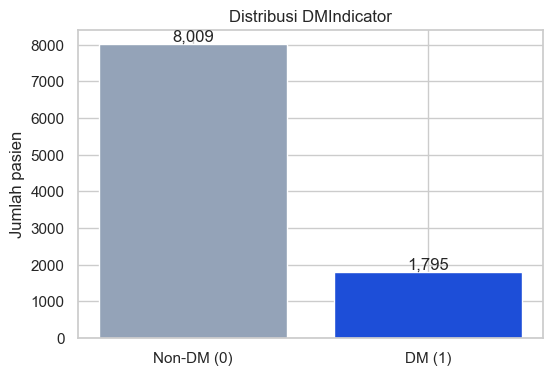

### Quality checks penting

,metric,count
0,Jumlah pasien final,9804
1,Jumlah fitur final,2499
2,Pasien dibuang karena tanpa medication,112
3,Pasien dibuang karena tanpa transcript rebuild,32


In [67]:
eda_df = final_dataset.copy()

label_counts = eda_df["DMIndicator"].value_counts().sort_index()
label_pct = (label_counts / label_counts.sum() * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "pct": label_pct})
display(Markdown("### Distribusi label"))
display(label_summary)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Non-DM (0)", "DM (1)"], label_counts.values, color=["#94A3B8", "#1D4ED8"])
ax.set_title("Distribusi DMIndicator")
ax.set_ylabel("Jumlah pasien")
for i, v in enumerate(label_counts.values):
    ax.text(i, v + max(label_counts.values) * 0.01, f"{v:,}", ha="center")
plt.show()

quality_checks = pd.DataFrame([
    {"metric": "Jumlah pasien final", "count": int(eda_df.shape[0])},
    {"metric": "Jumlah fitur final", "count": int(eda_df.shape[1] - 2)},
    {"metric": "Pasien dibuang karena tanpa medication", "count": int(len(base_keys - set(medication_old["PatientGuid"])))},
    {"metric": "Pasien dibuang karena tanpa transcript rebuild", "count": int(len(base_keys - set(transcript_rebuilt["PatientGuid"])))},
])
display(Markdown("### Quality checks penting"))
display(quality_checks)

### Rata-rata fitur numerik menurut target

,mean_non_dm,mean_dm,abs_diff
Weight_Mean,175.9670,194.4180,18.4510
Age,52.3310,64.4760,12.1450
SystolicBP_Mean,125.1840,131.7870,6.6020
BMI_Mean,28.3330,31.4710,3.1380
DiagnosisCount,9.1070,11.5280,2.4210
Weight_NObs,5.6560,7.1590,1.5030
Height_NObs,5.6550,7.1580,1.5030
VisitCount,5.1970,6.3420,1.1450
DiastolicBP_Mean,76.9470,76.5880,0.3590
RespiratoryRate_Mean,16.6430,16.9170,0.2730


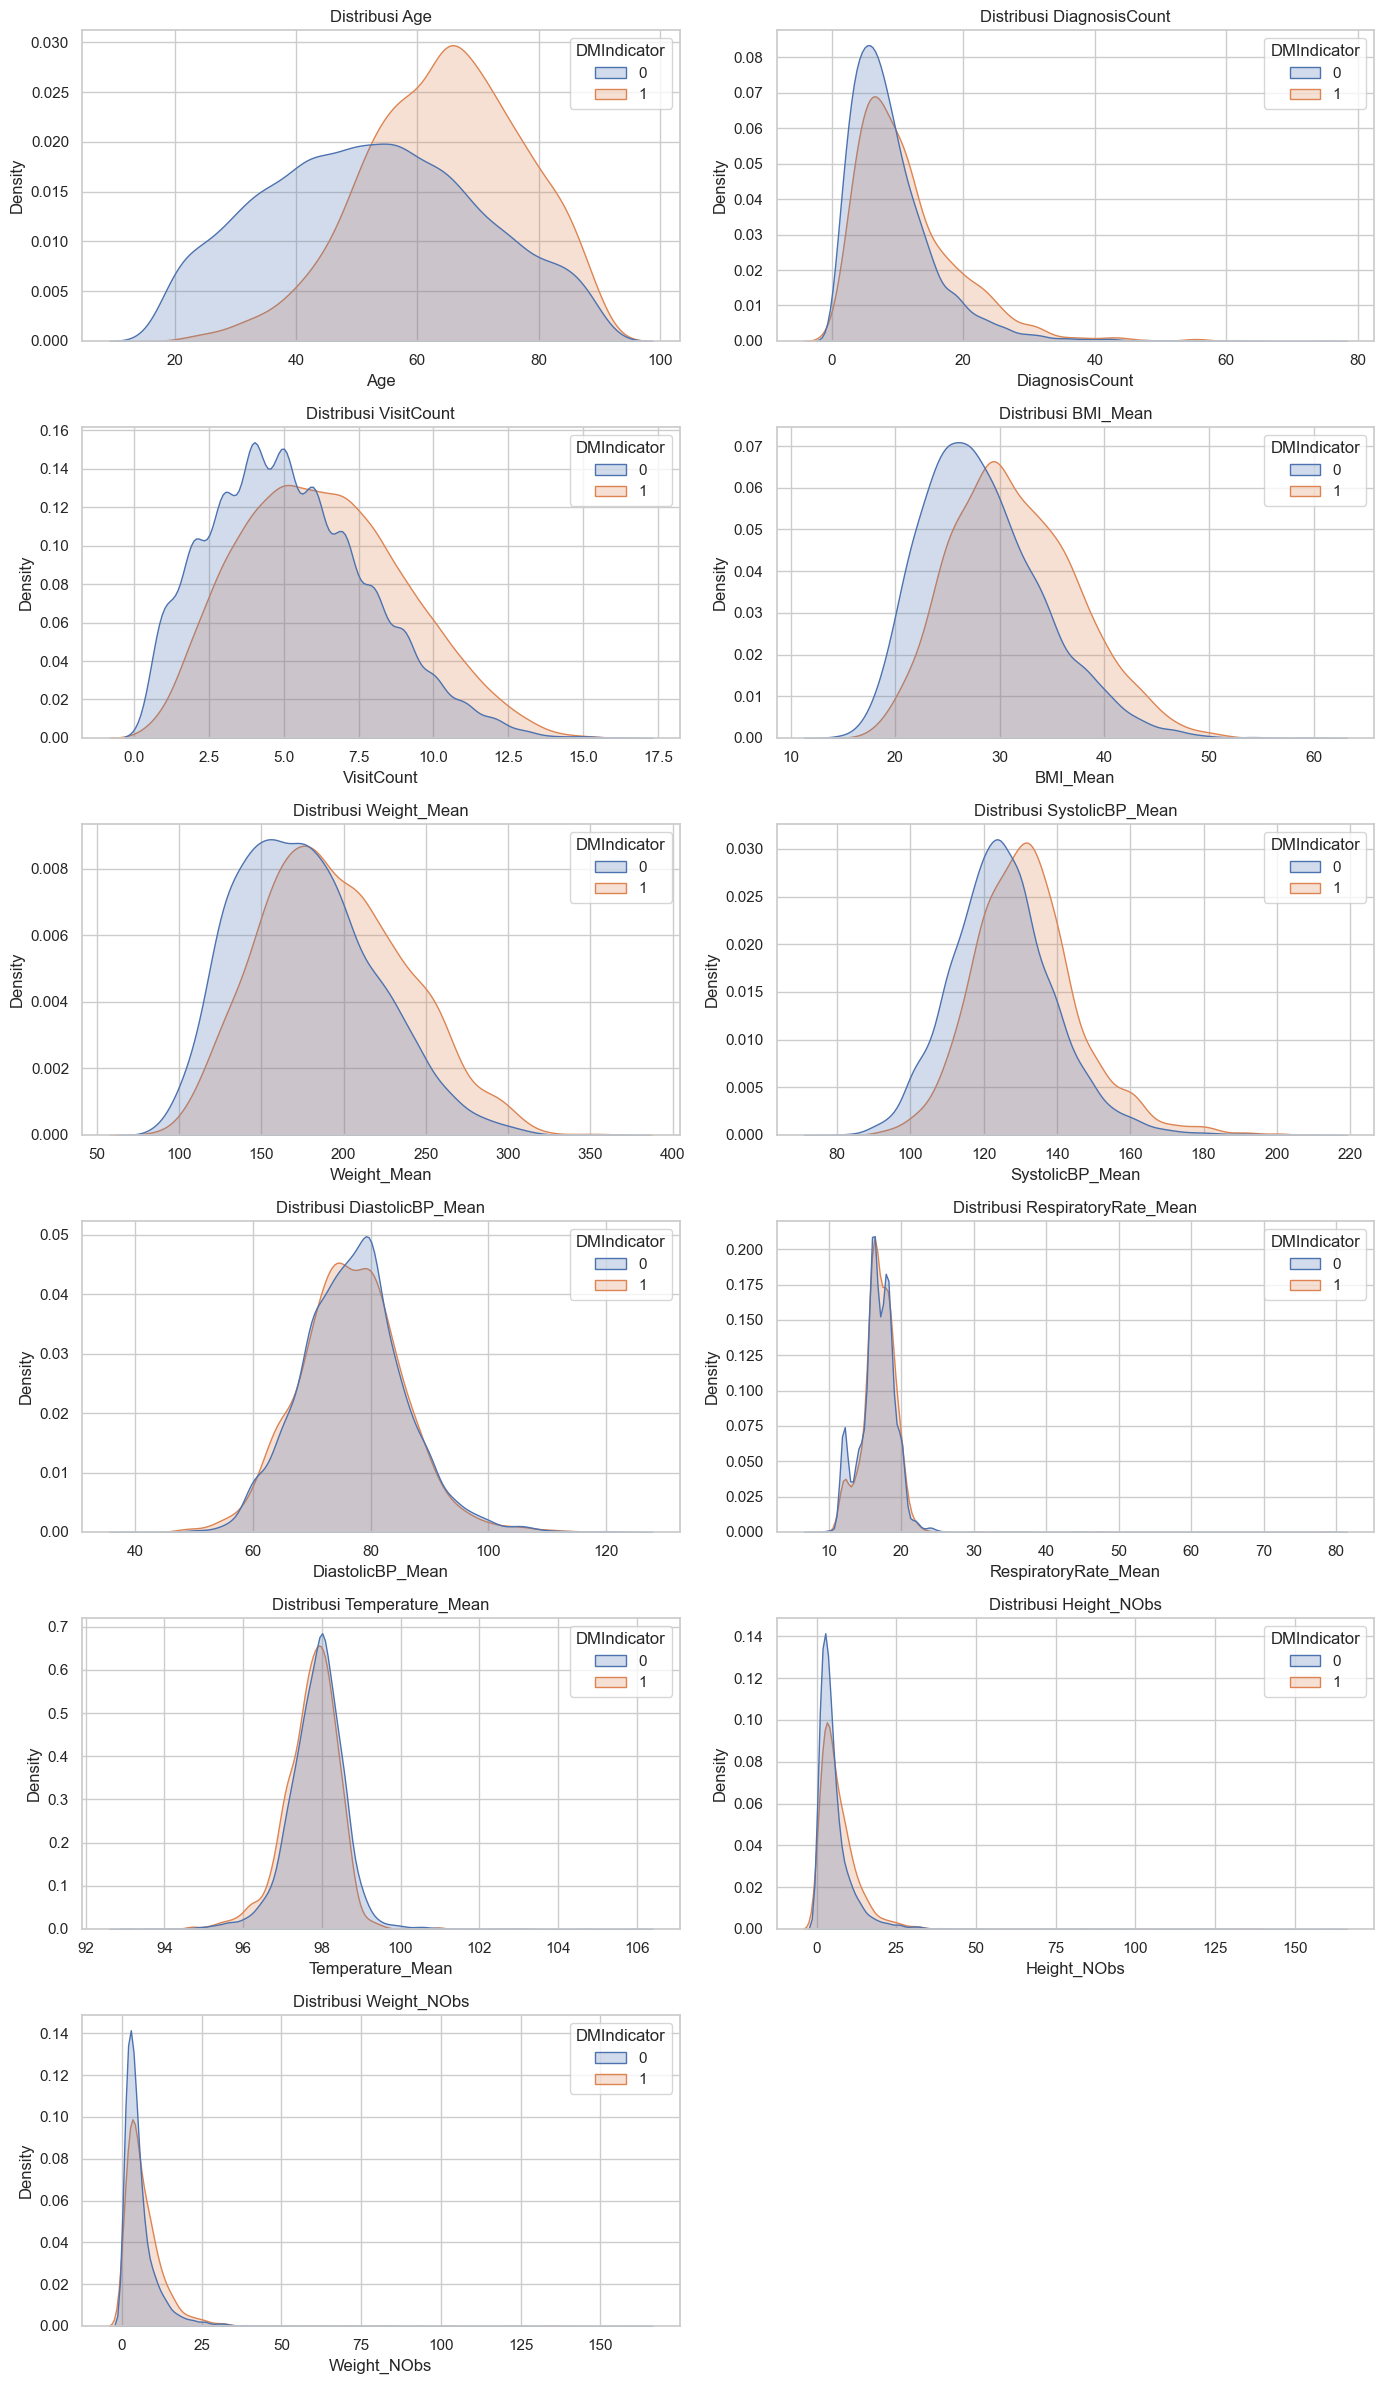

In [68]:
selected_numeric = [
    "Age",
    "DiagnosisCount",
    "VisitCount",
    "BMI_Mean",
    "Weight_Mean",
    "SystolicBP_Mean",
    "DiastolicBP_Mean",
    "RespiratoryRate_Mean",
    "Temperature_Mean",
    "Height_NObs",
    "Weight_NObs",
]
selected_numeric = [c for c in selected_numeric if c in eda_df.columns]

summary_by_target = eda_df.groupby("DMIndicator")[selected_numeric].mean().T
summary_by_target.columns = ["mean_non_dm", "mean_dm"]
summary_by_target["abs_diff"] = (summary_by_target["mean_dm"] - summary_by_target["mean_non_dm"]).abs()
summary_by_target = summary_by_target.sort_values("abs_diff", ascending=False)

display(Markdown("### Rata-rata fitur numerik menurut target"))
display(summary_by_target.round(3))

n_cols = 2
n_rows = int(np.ceil(len(selected_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(selected_numeric):
    ax = axes[idx]
    if HAS_SEABORN:
        sns.kdeplot(data=eda_df, x=col, hue="DMIndicator", fill=True, common_norm=False, ax=ax)
    else:
        ax.hist(eda_df.loc[eda_df["DMIndicator"] == 0, col], bins=30, alpha=0.55, label="0")
        ax.hist(eda_df.loc[eda_df["DMIndicator"] == 1, col], bins=30, alpha=0.55, label="1")
        ax.legend(title="DMIndicator")
    ax.set_title(f"Distribusi {col}")

for idx in range(len(selected_numeric), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

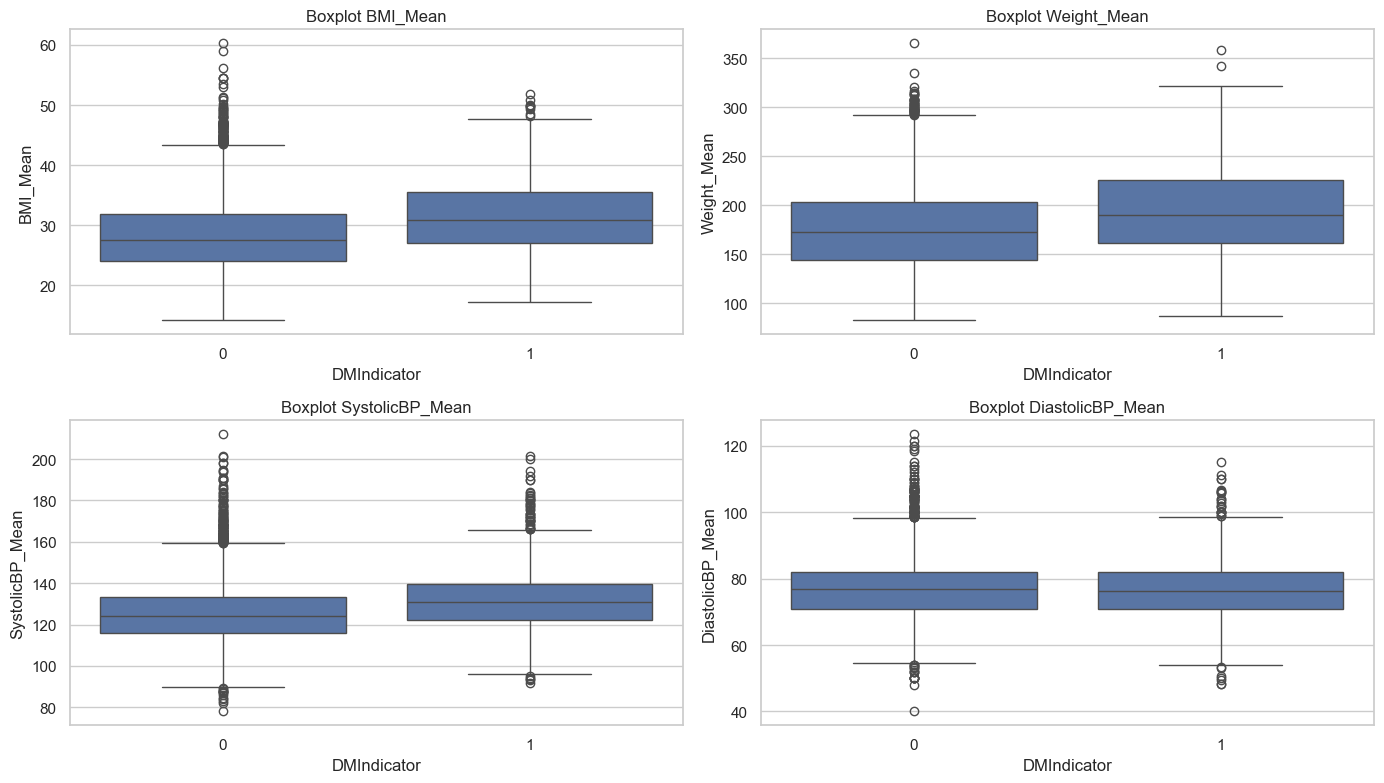

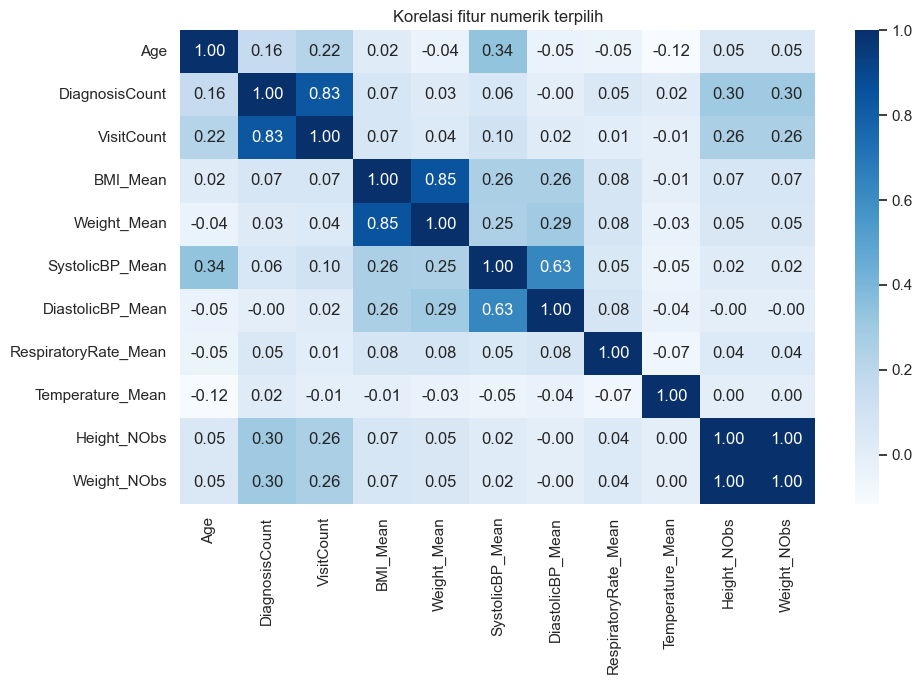

In [69]:
boxplot_cols = [c for c in ["BMI_Mean", "Weight_Mean", "SystolicBP_Mean", "DiastolicBP_Mean"] if c in eda_df.columns]
if boxplot_cols:
    n_cols = 2
    n_rows = int(np.ceil(len(boxplot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(boxplot_cols):
        ax = axes[idx]
        if HAS_SEABORN:
            sns.boxplot(data=eda_df, x="DMIndicator", y=col, ax=ax)
        else:
            eda_df.boxplot(column=col, by="DMIndicator", ax=ax)
        ax.set_title(f"Boxplot {col}")
        ax.set_xlabel("DMIndicator")

    for idx in range(len(boxplot_cols), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

corr_cols = [c for c in selected_numeric if c in eda_df.columns]
corr_df = eda_df[corr_cols].corr()
plt.figure(figsize=(10, 7))
if HAS_SEABORN:
    sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f")
else:
    plt.imshow(corr_df, cmap="Blues")
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.colorbar()
plt.title("Korelasi fitur numerik terpilih")
plt.tight_layout()
plt.show()

In [70]:
diagnosis_cols = [c for c in diagnosis_old.columns if c != "PatientGuid"]
physician_cols = [c for c in physician_old.columns if c != "PatientGuid"]

def top_mean_diff(df, columns, top_n=10):
    group_mean = df.groupby("DMIndicator")[columns].mean().T
    group_mean.columns = ["mean_non_dm", "mean_dm"]
    group_mean["abs_diff"] = (group_mean["mean_dm"] - group_mean["mean_non_dm"]).abs()
    return group_mean.sort_values("abs_diff", ascending=False).head(top_n)

diag_top = top_mean_diff(eda_df, diagnosis_cols, top_n=10)
phys_top = top_mean_diff(eda_df, physician_cols, top_n=10)

display(Markdown("### Top 10 diagnosis features berdasarkan beda mean"))
display(diag_top.round(4))

display(Markdown("### Top 10 physician specialty features berdasarkan beda mean"))
display(phys_top.round(4))

eda_notes = [
    "EDA dilakukan di atas final dataset, bukan dataset antara.",
    "Transcript yang dianalisis di sini adalah hasil rebuild dari d2, bukan transcript lama.",
    "Label tetap tidak seimbang, jadi recall dan PR-AUC akan penting pada tahap modeling.",
    "Medication dan diagnosis masih perlu diawasi karena berpotensi leakage terhadap label diabetes.",
]

display(Markdown("### Insight awal dari EDA"))
for note in eda_notes:
    display(Markdown(f"- {note}"))

### Top 10 diagnosis features berdasarkan beda mean

,mean_non_dm,mean_dm,abs_diff
DiagnosisCount,9.1070,11.5276,2.4206
VisitCount,5.1974,6.3421,1.1447
Icd9_390-459,0.7485,1.5900,0.8414
Icd9_240-279,0.9171,1.6435,0.7264
Icd9_780-799,1.2727,1.5448,0.2722
Icd9_710-739,1.0745,1.2981,0.2235
Icd9_580-629,0.4762,0.6100,0.1338
Icd9_520-579,0.4487,0.5610,0.1123
Icd9_E-V,0.7910,0.6891,0.1018
Icd9_280-289,0.0911,0.1816,0.0905


### Top 10 physician specialty features berdasarkan beda mean

,mean_non_dm,mean_dm,abs_diff
PhySp_Internal_Medicine,3.5692,6.4841,2.9149
PhySp_General_Practice,0.8150,1.5070,0.6920
PhySp_Psychiatry,0.4152,0.1677,0.2475
PhySp_Unknown,0.2964,0.5426,0.2462
PhySp_Geriatric_Medicine,0.2493,0.4540,0.2047
PhySp_Obstetrics_Gynecology,0.3234,0.1649,0.1585
PhySp_Nephrology,0.0372,0.1733,0.1361
PhySp_Podiatry,0.0784,0.1833,0.1049
PhySp_Pain_Medicine,0.1134,0.0178,0.0955
PhySp_Cardiovascular_Disease,0.1800,0.2513,0.0712


### Insight awal dari EDA

- EDA dilakukan di atas final dataset, bukan dataset antara.

- Transcript yang dianalisis di sini adalah hasil rebuild dari d2, bukan transcript lama.

- Label tetap tidak seimbang, jadi recall dan PR-AUC akan penting pada tahap modeling.

- Medication dan diagnosis masih perlu diawasi karena berpotensi leakage terhadap label diabetes.

### Kesimpulan Sementara Tahap EDA

Eksplorasi awal menunjukkan bahwa final dataset sudah memiliki pola yang cukup jelas untuk dilanjutkan ke tahap modelling.

- Distribusi label masih tidak seimbang, dengan sekitar `81.69%` pasien non-diabetes dan `18.31%` pasien diabetes. Karena itu, evaluasi model nantinya perlu menekankan metrik seperti recall, F1-score, dan PR-AUC, bukan akurasi saja.
- Kelompok diabetes cenderung memiliki nilai yang lebih tinggi pada beberapa variabel penting seperti `Age`, `Weight_Mean`, `BMI_Mean`, dan `SystolicBP_Mean`.
- Variabel seperti `DiagnosisCount`, `VisitCount`, beberapa kelompok diagnosis ICD, serta specialty seperti `Internal Medicine` tampak menunjukkan perbedaan yang cukup nyata antara kelompok diabetes dan non-diabetes.
- Pola ini memberi indikasi bahwa data yang sudah dibentuk memang mengandung sinyal prediktif, tetapi fitur diagnosis dan medication tetap perlu diawasi pada tahap modelling karena berpotensi membawa leakage terhadap label.

Secara umum, hasil EDA awal mendukung bahwa dataset ini layak dilanjutkan ke tahap imputasi, penyusunan pipeline modelling, dan interpretasi model menggunakan XAI.

## 4. Baseline Modelling

Bagian ini tetap mempertahankan kelompok model utama yang sudah direncanakan di proposal, tetapi pipeline pemodelannya disesuaikan dengan bentuk fitur pada dataset akhir yang sekarang.

Penyesuaian ini penting karena fitur yang tersedia setelah proses integrasi ternyata tidak sepenuhnya sama dengan asumsi awal proposal. Pada dataset akhir, banyak fitur diagnosis, medication, dan physician specialty berbentuk **count**, **frequency**, atau nilai sangat sparse, bukan sekadar indikator biner sederhana.

Karena itu, baseline modelling pada notebook ini disusun dengan prinsip berikut:
- pembagian data tetap dilakukan secara stratified agar distribusi kelas terjaga,
- imputasi dilakukan di dalam pipeline agar tidak terjadi data leakage,
- fitur diperlakukan berdasarkan **struktur aktualnya**, yaitu kategorikal, numerik binary-like, serta numerik count/frequency/continuous,
- scaling diterapkan terutama untuk model yang sensitif terhadap skala seperti Logistic Regression, SVM, dan KNN,
- dan evaluasi difokuskan pada metrik yang relevan untuk data tidak seimbang seperti recall, F1-score, ROC-AUC, dan PR-AUC.

Pada tahap ini, penanganan class imbalance difokuskan terlebih dahulu pada tingkat algoritma. Eksperimen dengan **SMOTE** tidak dijadikan langkah utama pipeline dasar, tetapi akan disiapkan sebagai pembanding pada tahap eksperimen lanjutan.

In [ ]:
import warnings

from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
demographic_categorical_cols = [c for c in ["Gender", "State"] if c in final_dataset.columns]
demographic_numeric_cols = [c for c in ["Age"] if c in final_dataset.columns]

transcript_prefixes = [
    "Height", "Weight", "BMI", "SystolicBP", "DiastolicBP", "RespiratoryRate", "Temperature"
]
transcript_cols_model = [
    c for c in final_dataset.columns
    if any(c.startswith(f"{prefix}_") for prefix in transcript_prefixes)
]
diagnosis_cols_model = [c for c in diagnosis_old.columns if c != "PatientGuid" and c in final_dataset.columns]
physician_cols_model = [c for c in physician_old.columns if c != "PatientGuid" and c in final_dataset.columns]
medication_cols_model = [
    c for c in medication_old.columns
    if c not in ["PatientGuid", "DMIndicator"] and c in final_dataset.columns
]

all_candidate_cols = list(dict.fromkeys(
    demographic_categorical_cols
    + demographic_numeric_cols
    + transcript_cols_model
    + diagnosis_cols_model
    + physician_cols_model
    + medication_cols_model
))

def is_binary_like_series(series):
    values = set(pd.Series(series.dropna().unique()).tolist())
    return len(values) > 0 and values.issubset({0, 1, 0.0, 1.0})

constant_cols_global = [
    c for c in all_candidate_cols
    if final_dataset[c].nunique(dropna=False) <= 1
]
binary_like_cols_global = [
    c for c in all_candidate_cols
    if c not in constant_cols_global
    and pd.api.types.is_numeric_dtype(final_dataset[c])
    and is_binary_like_series(final_dataset[c])
]
nonbinary_numeric_cols_global = [
    c for c in all_candidate_cols
    if c not in constant_cols_global
    and pd.api.types.is_numeric_dtype(final_dataset[c])
    and c not in binary_like_cols_global
]

feature_sets = {
    "Demografi + Transcript": demographic_categorical_cols + demographic_numeric_cols + transcript_cols_model,
    "+ Diagnosis": demographic_categorical_cols + demographic_numeric_cols + transcript_cols_model + diagnosis_cols_model,
    "+ Diagnosis + Physician": demographic_categorical_cols + demographic_numeric_cols + transcript_cols_model + diagnosis_cols_model + physician_cols_model,
    "+ Diagnosis + Physician + Medication": demographic_categorical_cols + demographic_numeric_cols + transcript_cols_model + diagnosis_cols_model + physician_cols_model + medication_cols_model,
}

feature_sets = {
    name: [c for c in list(dict.fromkeys(cols)) if c not in constant_cols_global]
    for name, cols in feature_sets.items()
}

column_role_summary_df = pd.DataFrame([
    {"role": "Demographic categorical", "n_columns": len(demographic_categorical_cols)},
    {"role": "Demographic numeric", "n_columns": len(demographic_numeric_cols)},
    {"role": "Transcript numeric", "n_columns": len(transcript_cols_model)},
    {"role": "Diagnosis numeric", "n_columns": len(diagnosis_cols_model)},
    {"role": "Physician numeric", "n_columns": len(physician_cols_model)},
    {"role": "Medication numeric", "n_columns": len(medication_cols_model)},
    {"role": "Constant columns removed", "n_columns": len(constant_cols_global)},
    {"role": "Binary-like numeric", "n_columns": len(binary_like_cols_global)},
    {"role": "Non-binary numeric", "n_columns": len(nonbinary_numeric_cols_global)},
])

experiment_plan_df = pd.DataFrame([
    {
        "feature_set": name,
        "n_features_after_filter": len(cols),
        "n_categorical": int(final_dataset[cols].select_dtypes(exclude=np.number).shape[1]),
        "n_binary_like_numeric": int(sum(c in binary_like_cols_global for c in cols)),
        "n_nonbinary_numeric": int(sum(c in nonbinary_numeric_cols_global for c in cols)),
    }
    for name, cols in feature_sets.items()
])

display(Markdown("### Ringkasan struktur fitur untuk modelling"))
display(column_role_summary_df)

display(Markdown("### Rancangan feature set untuk baseline"))
display(experiment_plan_df)

### Interpretasi Sebelum Running Baseline

Sebelum eksperimen dijalankan, ada beberapa hipotesis kerja yang ingin diuji.

- **Logistic Regression** tetap dipakai sebagai pembanding awal karena mudah dijelaskan dan baik untuk melihat apakah sinyal dalam data dapat ditangkap secara relatif linear.
- **SVM** dan **KNN** dipertahankan sesuai rencana model pada proposal, tetapi keduanya akan sangat bergantung pada kualitas scaling karena sensitif terhadap skala fitur.
- **Gradient Boosting**, **XGBoost**, dan **LightGBM** dipakai untuk melihat apakah model boosting mampu menangkap pola yang lebih kompleks dibanding model baseline klasik.
- Feature set **Demografi + Transcript** menjadi fondasi utama yang paling bersih secara klinis. Jika performanya sudah baik, maka transcript hasil rebuild benar-benar memberikan nilai tambah.
- Jika performa melonjak terutama setelah **Diagnosis**, **Physician**, atau **Medication** dimasukkan, maka hasil tersebut harus dibaca hati-hati karena ada kemungkinan model memanfaatkan sinyal yang sangat dekat dengan label diabetes.
- Karena struktur fitur saat ini banyak berisi count, frequency, dan sparse numeric features, pipeline tidak lagi mengasumsikan semua fitur tambahan sebagai biner. Perlakuan fitur akan mengikuti bentuk aktual data.

Pada tahap baseline ini, ketidakseimbangan kelas ditangani terutama lewat pengaturan algoritma. **SMOTE** belum dimasukkan ke pipeline dasar agar pengaruhnya nanti bisa diuji secara terpisah sebagai eksperimen pembanding.

Karena label tidak seimbang, fokus utama pembacaan hasil nanti adalah **recall, F1-score, dan PR-AUC**, bukan akurasi semata.

In [ ]:
TARGET_COL = "DMIndicator"
RANDOM_STATE = 42
SCALE_SENSITIVE_MODELS = {"Logistic Regression", "SVM", "KNN"}

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def split_feature_roles(df, feature_cols):
    numeric_cols = df[feature_cols].select_dtypes(include=np.number).columns.tolist()
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]
    binary_like_cols = [c for c in numeric_cols if is_binary_like_series(df[c])]
    nonbinary_numeric_cols = [c for c in numeric_cols if c not in binary_like_cols]
    return categorical_cols, binary_like_cols, nonbinary_numeric_cols

def build_preprocessor(df, feature_cols, model_name):
    categorical_cols, binary_like_cols, nonbinary_numeric_cols = split_feature_roles(df, feature_cols)
    transformers = []

    if nonbinary_numeric_cols:
        nonbinary_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
        if model_name in SCALE_SENSITIVE_MODELS:
            nonbinary_steps.append(("scaler", StandardScaler()))
        transformers.append(("num_nonbinary", Pipeline(nonbinary_steps), nonbinary_numeric_cols))

    if binary_like_cols:
        binary_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ])
        transformers.append(("num_binary", binary_pipe, binary_like_cols))

    if categorical_cols:
        categorical_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_ohe()),
        ])
        transformers.append(("cat", categorical_pipe, categorical_cols))

    preprocessor = ColumnTransformer(transformers, remainder="drop", sparse_threshold=0.0)
    role_info = {
        "categorical_cols": categorical_cols,
        "binary_like_cols": binary_like_cols,
        "nonbinary_numeric_cols": nonbinary_numeric_cols,
    }
    return preprocessor, role_info

def get_model_fit_kwargs(model_name, y_train):
    if model_name == "Gradient Boosting":
        return {"model__sample_weight": compute_sample_weight(class_weight="balanced", y=y_train)}
    return {}

def get_positive_scores(pipeline, X):
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X)[:, 1]
    if hasattr(pipeline, "decision_function"):
        raw_scores = pipeline.decision_function(X)
        return 1 / (1 + np.exp(-raw_scores))
    raise AttributeError("Model tidak menyediakan predict_proba maupun decision_function.")

def evaluate_experiment(df, feature_set_name, feature_cols, model_name, model_builder, train_idx, test_idx):
    X = df[feature_cols].copy()
    y = df[TARGET_COL].astype(int)

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    preprocessor, role_info = build_preprocessor(df, feature_cols, model_name=model_name)
    model = model_builder(y_train)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    fit_kwargs = get_model_fit_kwargs(model_name, y_train)
    pipeline.fit(X_train, y_train, **fit_kwargs)

    y_pred = pipeline.predict(X_test)
    y_score = get_positive_scores(pipeline, X_test)
    cm = confusion_matrix(y_test, y_pred)

    result = {
        "feature_set": feature_set_name,
        "model": model_name,
        "n_features": len(feature_cols),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

    artifact = {
        "pipeline": pipeline,
        "confusion_matrix": cm,
        "role_info": role_info,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_score": y_score,
    }
    return result, artifact

train_idx, test_idx = train_test_split(
    final_dataset.index,
    test_size=0.3,
    stratify=final_dataset[TARGET_COL],
    random_state=RANDOM_STATE,
)

y_train_ref = final_dataset.loc[train_idx, TARGET_COL].astype(int)
neg_pos_ratio = float((y_train_ref == 0).sum() / (y_train_ref == 1).sum())

model_builders = {
    "Logistic Regression": lambda y_train: LogisticRegression(
        max_iter=1000,
        solver="saga",
        penalty="l2",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "SVM": lambda y_train: SVC(
        kernel="linear",
        class_weight="balanced",
        probability=False,
        random_state=RANDOM_STATE,
    ),
    "KNN": lambda y_train: KNeighborsClassifier(
        n_neighbors=11,
        weights="distance",
        metric="minkowski",
        p=2,
        n_jobs=1,
    ),
    "Gradient Boosting": lambda y_train: GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": lambda y_train: XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=neg_pos_ratio,
        tree_method="hist",
        n_jobs=1,
        random_state=RANDOM_STATE,
    ),
    "LightGBM": lambda y_train: LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbosity=-1,
    ),
}

baseline_results = []
baseline_artifacts = {}

for feature_set_name, feature_cols in feature_sets.items():
    for model_name, model_builder in model_builders.items():
        print(f"Running {model_name} | {feature_set_name} ...")
        result, artifact = evaluate_experiment(
            final_dataset,
            feature_set_name,
            feature_cols,
            model_name,
            model_builder,
            train_idx,
            test_idx,
        )
        experiment_key = f"{model_name}__{feature_set_name}"
        result["experiment_key"] = experiment_key
        baseline_results.append(result)
        baseline_artifacts[experiment_key] = artifact

baseline_results_df = pd.DataFrame(baseline_results).sort_values(
    ["pr_auc", "recall", "f1"], ascending=False
).reset_index(drop=True)

BASELINE_RESULT_PATH = OUTPUT_DIR / "baseline_model_results.csv"
baseline_results_df.to_csv(BASELINE_RESULT_PATH, index=False)

display(Markdown("### Hasil baseline modelling"))
display(baseline_results_df.round(4))
print("Saved baseline results:", BASELINE_RESULT_PATH)

In [ ]:
pr_auc_pivot = baseline_results_df.pivot(index="feature_set", columns="model", values="pr_auc")
recall_pivot = baseline_results_df.pivot(index="feature_set", columns="model", values="recall")

display(Markdown("### PR-AUC per feature set dan model"))
display(pr_auc_pivot.round(4))

display(Markdown("### Recall per feature set dan model"))
display(recall_pivot.round(4))

best_row = baseline_results_df.iloc[0].copy()
best_key = best_row["experiment_key"]
best_artifact = baseline_artifacts[best_key]
cm = best_artifact["confusion_matrix"]

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-DM", "Actual DM"],
    columns=["Pred Non-DM", "Pred DM"],
)
display(Markdown("### Confusion matrix eksperimen terbaik"))
display(cm_df)

plt.figure(figsize=(8, 4))
pr_auc_pivot.plot(kind="bar", figsize=(10, 5))
plt.ylabel("PR-AUC")
plt.title("Perbandingan PR-AUC antar model dan feature set")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
baseline_only_name = "Demografi + Transcript"
full_feature_name = "+ Diagnosis + Physician + Medication"

best_model_name = best_row["model"]
baseline_same_model = baseline_results_df[
    (baseline_results_df["model"] == best_model_name) &
    (baseline_results_df["feature_set"] == baseline_only_name)
].iloc[0]

full_same_model = baseline_results_df[
    (baseline_results_df["model"] == best_model_name) &
    (baseline_results_df["feature_set"] == full_feature_name)
].iloc[0]

delta_pr = float(full_same_model["pr_auc"] - baseline_same_model["pr_auc"])
delta_recall = float(full_same_model["recall"] - baseline_same_model["recall"])

if any(token in str(best_row["feature_set"]) for token in ["Diagnosis", "Medication"]):
    leakage_note = (
        "Eksperimen terbaik melibatkan diagnosis, physician, atau medication. Karena ketiga kelompok fitur ini cukup dekat dengan kondisi klinis pasien, hasilnya perlu dibaca hati-hati sebelum disimpulkan sebagai kemampuan prediksi yang benar-benar bersifat dini."
    )
else:
    leakage_note = (
        "Eksperimen terbaik tidak terlalu bergantung pada kelompok fitur yang sangat dekat dengan label, sehingga sinyal prediktifnya relatif lebih bersih untuk dibaca secara klinis."
    )

post_run_md = f"""
### Interpretasi Setelah Running Baseline

Dari seluruh eksperimen baseline, kombinasi terbaik pada holdout test set saat ini adalah **{best_row['model']}** dengan feature set **{best_row['feature_set']}**.

Ringkasan performa eksperimen terbaik:
- PR-AUC: `{best_row['pr_auc']:.4f}`
- ROC-AUC: `{best_row['roc_auc']:.4f}`
- Recall: `{best_row['recall']:.4f}`
- Precision: `{best_row['precision']:.4f}`
- F1-score: `{best_row['f1']:.4f}`

Jika model terbaik yang sama dibandingkan antara feature set paling bersih (**{baseline_only_name}**) dan feature set paling lengkap (**{full_feature_name}**), maka kenaikan PR-AUC sebesar `{delta_pr:.4f}` dan kenaikan recall sebesar `{delta_recall:.4f}`.

{leakage_note}

Dari sisi pipeline, hasil ini juga harus dibaca bersama fakta bahwa struktur fitur saat ini banyak berisi count, frequency, dan fitur numeric yang sangat sparse. Karena itu, baseline ini lebih representatif terhadap kondisi data aktual dibanding asumsi awal bahwa sebagian besar fitur tambahan hanya berbentuk biner.

Langkah berikutnya yang paling masuk akal adalah melakukan **eksperimen SMOTE sebagai pembanding**, **threshold tuning**, serta **uji leakage yang lebih tegas** dengan membandingkan model tanpa diagnosis dan tanpa medication.
"""

display(Markdown(post_run_md))